Assessing Urban Green Equality in Southeast Michigan

Problem Statement

Urban green spaces provide important environmental, recreational, and health benefits, but these benefits may not be distributed equally across urban neighborhoods. Scholars have found unequal distributions of urban green space in the United States at the city level scale(Rigolon 2016; Byrne 2017; Williams et al 2020). Howerver, the research on green space at the regional scale level is comparatively sparse. To complement and build on prior findinds, this project assesses urban green equality across the Southeast Michigan Council of Governments (SEMCOG) region by examining the distribution of green space across census tracts. Using SEMCOG green space data, Census tract boundaries from pygris, and American Community Survey demographic data from censusdis, the study calculates tract-level green space availability and evaluates whether neighborhoods with higher median household income have greater access to green space. The final tract-level GeoDataFrame is then published to ArcGIS Online, and an interactive web map is created using the ArcGIS Python API.

Research Questions

This mini project is guided by these questions
How is green space distributed across census tracts in Southeast Michigan?
How much green space is available per resident (1000) across census tracts?
Is there a relationship between median household income and green space availability?

Variables

ACS variables

B01003_001E = total population
B19013_001E = median household income

Derived green metrics

green_acres
green_pct_tract
green_acres_per_1000

In [1]:
# Installing Packages
!pip install pandas
!pip install geopandas 
!pip install matplotlib
!pip install numpy
!pip install pygris
!pip install censusdis
!pip install mapclassify

In [2]:
#Importing Libraries
import os
import zipfile
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import pygris
import censusdis.data as ced



In [3]:
!pip install arcgis

In [4]:
# Project Settings
STATE_FIPS = "26"   # Michigan
ACS_YEAR = 2024
TRACT_YEAR = 2024

SEMCOG_COUNTIES = {
    "Livingston": "093",
    "Macomb": "099",
    "Monroe": "115",
    "Oakland": "125",
    "St. Clair": "147",
    "Washtenaw": "161",
    "Wayne": "163"
}

GREENSPACE_PATH = r"C:\Users\oj640\OneDrive - Western Michigan University\Desktop\GIS Project and Programming\Semester Project\SEMCOG Project\Parks_Amenities_2023\Parks_Amenities_2023.shp"
OUTPUT_DIR = r"C:\Users\oj640\OneDrive - Western Michigan University\Desktop\GIS Project and Programming\Semester Project\SEMCOG Project\Parks_Amenities_2023"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
# Study Area Description
print("Study Area: SEMCOG Region")
for county, fips in SEMCOG_COUNTIES.items():
    print(county, fips) 

Study Area: SEMCOG Region
Livingston 093
Macomb 099
Monroe 115
Oakland 125
St. Clair 147
Washtenaw 161
Wayne 163


In [6]:
# Loading administrative boundaries with pygris

counties = pygris.counties(
    state="MI",
    cb=True,
    year=TRACT_YEAR,
    cache=True
)

# Filtering only SEMCOG counties
semcog_names = list(SEMCOG_COUNTIES.keys())

counties = counties[counties["NAME"].isin(semcog_names)]

counties = counties[["GEOID", "NAME", "geometry"]].copy()

counties.head()

Using FIPS code '26' for input 'MI'


,GEOID,NAME,geometry
68,26115,Monroe,"POLYGON ((-83.77392 42.08243, -83.71187 42.083..."
447,26163,Wayne,"MULTIPOLYGON (((-83.19159 42.03537, -83.18993 ..."
802,26099,Macomb,"POLYGON ((-83.10289 42.88865, -83.04297 42.890..."
803,26147,St. Clair,"POLYGON ((-82.99626 43.1541, -82.94365 43.1555..."
2051,26125,Oakland,"POLYGON ((-83.68938 42.87126, -83.67056 42.871..."


In [7]:
#Tract Level
tract_list = []

for county_name in SEMCOG_COUNTIES.keys():
    gdf = pygris.tracts(
        state="MI",
        county=county_name,
        cb=True,
        year=TRACT_YEAR,
        cache=True
    )
    tract_list.append(gdf)

tracts = pd.concat(tract_list, ignore_index=True)
tracts = gpd.GeoDataFrame(tracts, geometry="geometry", crs=tract_list[0].crs)
tracts = tracts[["GEOID", "NAME", "COUNTYFP", "TRACTCE", "geometry"]].copy()

tracts.head()

Using FIPS code '26' for input 'MI'
Using FIPS code '093' for input 'Livingston'
Using FIPS code '26' for input 'MI'
Using FIPS code '099' for input 'Macomb'
Using FIPS code '26' for input 'MI'
Using FIPS code '115' for input 'Monroe'
Using FIPS code '26' for input 'MI'
Using FIPS code '125' for input 'Oakland'
Using FIPS code '26' for input 'MI'
Using FIPS code '147' for input 'St. Clair'
Using FIPS code '26' for input 'MI'
Using FIPS code '161' for input 'Washtenaw'
Using FIPS code '26' for input 'MI'
Using FIPS code '163' for input 'Wayne'


,GEOID,NAME,COUNTYFP,TRACTCE,geometry
0,26093721100,7211,093,721100,"POLYGON ((-84.03952 42.7785, -84.02109 42.7788..."
1,26093713100,7131,093,713100,"POLYGON ((-83.76115 42.69308, -83.72918 42.694..."
2,26093741602,7416.02,093,741602,"POLYGON ((-83.792 42.51588, -83.79058 42.51693..."
3,26093712101,7121.01,093,712101,"POLYGON ((-83.91737 42.68786, -83.87793 42.689..."
4,26093743500,7435,093,743500,"POLYGON ((-83.90897 42.47523, -83.90579 42.474..."


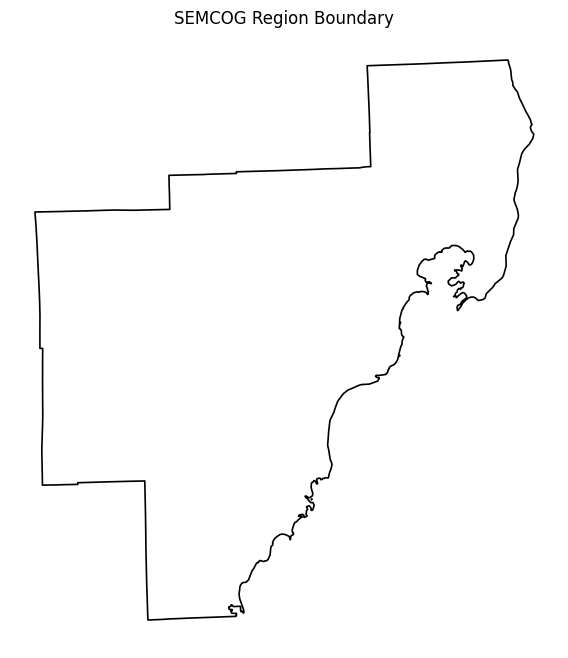

In [8]:
# SEMCOG Regional Boundary
region_boundary = counties.dissolve().reset_index(drop=True)
region_boundary["region_name"] = "SEMCOG Region"

fig, ax = plt.subplots(figsize=(8, 8))
region_boundary.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1.2)
ax.set_title("SEMCOG Region Boundary")
ax.axis("off")
plt.show()

In [9]:
#Downloading ACS data with censusdis 
ACS_VARS = [
    "NAME",
    "B01003_001E",   # total population
    "B19013_001E"    # median household income
]    
acs = ced.download(
    "acs/acs5",
    ACS_YEAR,
    ACS_VARS,
    state=STATE_FIPS,
    county=list(SEMCOG_COUNTIES.values()),
    tract="*"
)

acs.head()

,STATE,COUNTY,TRACT,NAME,B01003_001E,B19013_001E
0,26,093,710100,Census Tract 7101; Livingston County; Michigan,2825,133229.0
1,26,093,710300,Census Tract 7103; Livingston County; Michigan,5451,88308.0
2,26,093,710500,Census Tract 7105; Livingston County; Michigan,1906,125457.0
3,26,093,710700,Census Tract 7107; Livingston County; Michigan,1969,100865.0
4,26,093,711000,Census Tract 7110; Livingston County; Michigan,4145,105257.0


In [10]:
#Clean ACS data
acs["GEOID"] = acs["STATE"] + acs["COUNTY"] + acs["TRACT"]

acs = acs.rename(columns={
    "B01003_001E": "total_pop",
    "B19013_001E": "med_hh_income"
})

acs["total_pop"] = pd.to_numeric(acs["total_pop"], errors="coerce")
acs["med_hh_income"] = pd.to_numeric(acs["med_hh_income"], errors="coerce")

acs = acs[[
    "GEOID",
    "NAME",
    "total_pop",
    "med_hh_income"
]].copy()

acs.head()

,GEOID,NAME,total_pop,med_hh_income
0,26093710100,Census Tract 7101; Livingston County; Michigan,2825,133229.0
1,26093710300,Census Tract 7103; Livingston County; Michigan,5451,88308.0
2,26093710500,Census Tract 7105; Livingston County; Michigan,1906,125457.0
3,26093710700,Census Tract 7107; Livingston County; Michigan,1969,100865.0
4,26093711000,Census Tract 7110; Livingston County; Michigan,4145,105257.0


In [11]:
# Joining ACS to tracts
tracts = tracts.merge(acs, on="GEOID", how="left")

tracts.head()

,GEOID,NAME_x,COUNTYFP,TRACTCE,geometry,NAME_y,total_pop,med_hh_income
0,26093721100,7211,093,721100,"POLYGON ((-84.03952 42.7785, -84.02109 42.7788...",Census Tract 7211; Livingston County; Michigan,3230,86250.0
1,26093713100,7131,093,713100,"POLYGON ((-83.76115 42.69308, -83.72918 42.694...",Census Tract 7131; Livingston County; Michigan,4949,117500.0
2,26093741602,7416.02,093,741602,"POLYGON ((-83.792 42.51588, -83.79058 42.51693...",Census Tract 7416.02; Livingston County; Michigan,4086,110385.0
3,26093712101,7121.01,093,712101,"POLYGON ((-83.91737 42.68786, -83.87793 42.689...",Census Tract 7121.01; Livingston County; Michigan,3193,100740.0
4,26093743500,7435,093,743500,"POLYGON ((-83.90897 42.47523, -83.90579 42.474...",Census Tract 7435; Livingston County; Michigan,1959,120341.0


In [12]:
# Checking missing values
tracts[["total_pop", "med_hh_income"]].isna().sum()

total_pop         0
med_hh_income    78
dtype: int64

In [13]:
# Loading SEMCOG Green space data
greenspace = gpd.read_file(GREENSPACE_PATH)

greenspace.head()

,camping,community_,snowboardi,notes,museum_int,park_locat,park_name,restrooms,ice_skatin,wildlife_w,...,monument_h,url,picnic_she,concession,walking_bi,dog_park,beach,objectid,owner_type,geometry
0,N,N,N,None,N,Detroit,Tarnow-Kirkwood Park,N,N,N,...,N,http://www.detroitmi.gov/Recreation,N,N,Y,N,N,1,3,"POLYGON ((13455030.115 307943.901, 13454943.18..."
1,Y,N,N,None,N,Dexter Township,Pinckney State Recreation Area,Y,N,Y,...,Y,http://www.michigandnr.com/parksandtrails/Deta...,Y,N,N,N,Y,2,3,"MULTIPOLYGON (((13214173.856 347447.749, 13214..."
2,N,N,N,None,N,Ann Arbor,Argo Nature Area,Y,N,Y,...,N,http://www.a2gov.org/departments/Parks-Recreat...,Y,N,Y,N,N,3,3,"MULTIPOLYGON (((13291771.774 293365.949, 13291..."
3,N,N,N,None,N,Chelsea,Pierce Park,N,N,N,...,N,http://city-chelsea.org/parksrec,Y,N,N,N,N,4,3,"POLYGON ((13217271.828 295061.265, 13217277.84..."
4,N,N,N,None,N,Canton Township,Pheasant Run Golf Course,Y,N,N,...,N,https://www.canton-mi.org/147/Parks,N,Y,N,N,N,5,3,"MULTIPOLYGON (((13358347.162 290511.433, 13358..."


In [14]:
# Inspecting structure
print(greenspace.columns.tolist())
print(greenspace.crs)
print(greenspace.geom_type.value_counts())

['camping', 'community_', 'snowboardi', 'notes', 'museum_int', 'park_locat', 'park_name', 'restrooms', 'ice_skatin', 'wildlife_w', 'equestrian', 'bmx_area', 'multipurpo', 'tennis_cou', 'farm_garde', 'park_owner', 'swimming_p', 'mountain_b', 'hiking_nat', 'natural_ar', 'gymnasium', 'park_id', 'fitness_eq', 'kayaking_c', 'volleyball', 'amphitheat', 'crosscount', 'geocaching', 'basketball', 'disc_golf_', 'play_area', 'soccer_fie', 'shooting_r', 'boating', 'SHAPE__Len', 'golf_cours', 'park_type', 'sledding_h', 'indoor_eve', 'water_park', 'ballfields', 'residents_', 'skate_park', 'entry_fee', 'acres_1', 'pickleball', 'shuffleboa', 'track', 'hunting_tr', 'SHAPE__Are', 'hockey', 'fishing', 'monument_h', 'url', 'picnic_she', 'concession', 'walking_bi', 'dog_park', 'beach', 'objectid', 'owner_type', 'geometry']
EPSG:2898
Polygon         2759
MultiPolygon     231
Name: count, dtype: int64


In [15]:
# Data cleaning
greenspace = greenspace.copy()
greenspace = greenspace[greenspace.geometry.notnull()].copy()
greenspace = greenspace[greenspace.geometry.is_valid].copy()

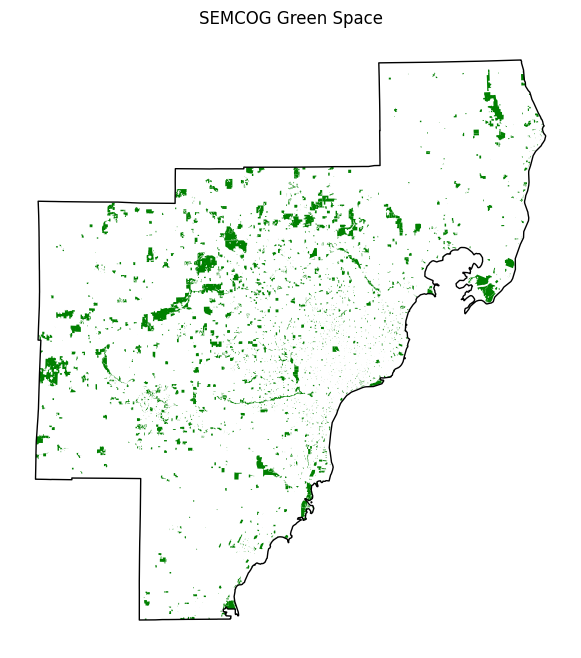

In [16]:
# Reprojecting and clipping
projected_crs = tracts.estimate_utm_crs()
projected_crs

tracts = tracts.to_crs(projected_crs)
counties = counties.to_crs(projected_crs)
region_boundary = region_boundary.to_crs(projected_crs)
greenspace = greenspace.to_crs(projected_crs)


# clipping green space to SEMCOG region
greenspace = gpd.clip(greenspace, region_boundary)
greenspace = greenspace.explode(index_parts=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 8))
greenspace.plot(ax=ax, color="green", edgecolor="none")
region_boundary.boundary.plot(ax=ax, color="black", linewidth=1)
ax.set_title("SEMCOG Green Space")
ax.axis("off")
plt.show()

In [17]:
# Computing SEMCOG Green metrics

#tract area
tracts["tract_sq_m"] = tracts.geometry.area
tracts["tract_acres"] = tracts["tract_sq_m"] / 4046.8564224

In [18]:
#intersect green space with tracts
greenspace_in_tracts = gpd.overlay(
    tracts[["GEOID", "geometry"]],
    greenspace[["geometry"]],
    how="intersection"
)

greenspace_in_tracts["green_sq_m"] = greenspace_in_tracts.geometry.area
greenspace_in_tracts["green_acres"] = greenspace_in_tracts["green_sq_m"] / 4046.8564224

greenspace_in_tracts.head()

,GEOID,geometry,green_sq_m,green_acres
0,26093721100,"POLYGON ((258185.808 4730295.29, 258186.119 47...",1.436561e+05,35.498193
1,26093721100,"POLYGON ((254493.382 4730996.147, 254461.237 4...",4.133739e+05,102.146907
2,26093721100,"POLYGON ((256903.081 4733718.68, 256905.26 473...",6.069945e+05,149.991615
3,26093721100,"POLYGON ((260931.432 4735133.284, 260569.913 4...",3.163854e+06,781.805324
4,26093713100,"POLYGON ((278131.013 4723929.057, 278133.189 4...",2.442601e+05,60.357984


In [19]:
# summarize green area by tract
green_summary = (
    greenspace_in_tracts
    .groupby("GEOID", as_index=False)[["green_sq_m", "green_acres"]]
    .sum()
)

green_summary.head()

,GEOID,green_sq_m,green_acres
0,26093710100,2.423150e+03,0.598773
1,26093710300,2.864550e+06,707.845698
2,26093710500,1.832619e+05,45.284992
3,26093710700,8.246064e+04,20.376469
4,26093711000,9.766452e+06,2413.342887


In [20]:
#merging back to tracts
tracts = tracts.merge(green_summary, on="GEOID", how="left")

tracts["green_sq_m"] = tracts["green_sq_m"].fillna(0)
tracts["green_acres"] = tracts["green_acres"].fillna(0)

tracts["green_pct_tract"] = (tracts["green_sq_m"] / tracts["tract_sq_m"]) * 100
tracts["green_acres_per_1000"] = np.where(
    tracts["total_pop"] > 0,
    (tracts["green_acres"] / tracts["total_pop"]) * 1000,
    np.nan
)

In [21]:
# Final Cleaning
tracts_final = tracts.copy()

tracts_final = tracts_final[
    (tracts_final["total_pop"].notna()) &
    (tracts_final["total_pop"] > 0)
].copy()

tracts_final["med_hh_income"] = tracts_final["med_hh_income"].replace({
    -666666666: np.nan,
    -333333333: np.nan
})

tracts_final["green_pct_tract"] = tracts_final["green_pct_tract"].clip(lower=0)

tracts_final.shape

(1424, 14)

In [22]:
# Saving Outputs             #export GeoPackage and CSV

gpkg_path = os.path.join(OUTPUT_DIR, "semcog_green_equality_tracts.gpkg")
csv_path = os.path.join(OUTPUT_DIR, "semcog_green_equality_tracts.csv")

tracts_final.to_file(gpkg_path, driver="GPKG")
tracts_final.drop(columns="geometry").to_csv(csv_path, index=False)

print(gpkg_path)
print(csv_path)

C:\Users\oj640\OneDrive - Western Michigan University\Desktop\GIS Project and Programming\Semester Project\SEMCOG Project\Parks_Amenities_2023\semcog_green_equality_tracts.gpkg
C:\Users\oj640\OneDrive - Western Michigan University\Desktop\GIS Project and Programming\Semester Project\SEMCOG Project\Parks_Amenities_2023\semcog_green_equality_tracts.csv


Summary table and descriptive stats

In [23]:
# Descriptive statistics
summary_stats = tracts_final[[
    "total_pop",
    "med_hh_income",
    "green_acres",
    "green_pct_tract",
    "green_acres_per_1000"
]].describe()

summary_stats

,total_pop,med_hh_income,green_acres,green_pct_tract,green_acres_per_1000
count,1424.000000,1397.000000,1424.000000,1424.000000,1424.000000
mean,3380.139045,82204.811739,131.872687,5.505522,48.742897
std,1447.452219,40692.776518,429.099858,8.263157,317.651514
min,4.000000,11864.000000,0.000000,0.000000,0.000000
25%,2362.000000,51207.000000,1.023495,0.207066,0.363964
50%,3213.500000,75489.000000,14.999753,2.366061,4.771056
75%,4219.500000,104697.000000,73.148679,6.919502,22.058662
max,9923.000000,250001.000000,5888.290570,81.405489,9686.781512


In [24]:
# Spearman correlation
corr = tracts_final[[
    "med_hh_income",
    "green_pct_tract",
    "green_acres_per_1000"
]].corr(method="spearman")

corr

,med_hh_income,green_pct_tract,green_acres_per_1000
med_hh_income,1.000000,0.236640,0.334922
green_pct_tract,0.236640,1.000000,0.908547
green_acres_per_1000,0.334922,0.908547,1.000000


Plots and charts

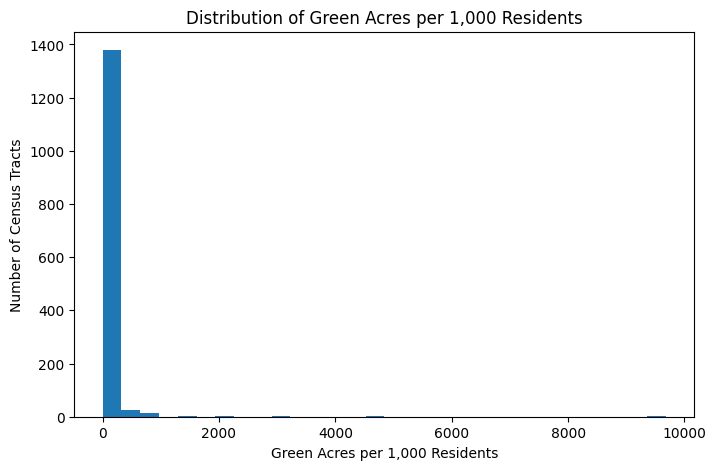

In [25]:
# histogram of green acres per 1,000 residents
plt.figure(figsize=(8, 5))
tracts_final["green_acres_per_1000"].dropna().plot(kind="hist", bins=30)
plt.title("Distribution of Green Acres per 1,000 Residents")
plt.xlabel("Green Acres per 1,000 Residents")
plt.ylabel("Number of Census Tracts")
plt.show()

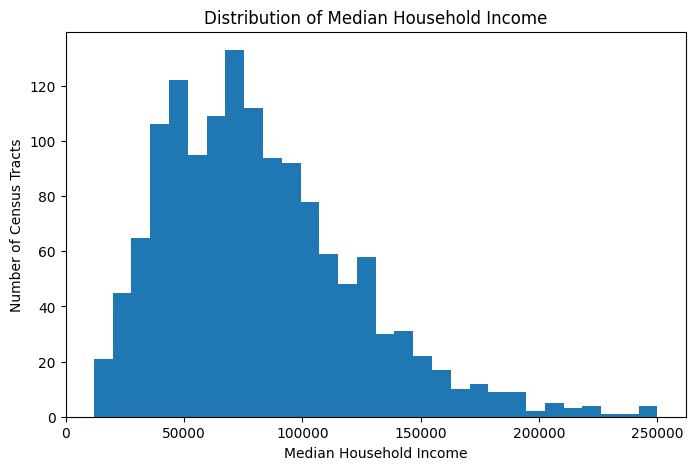

In [26]:
# histogram of median household income
plt.figure(figsize=(8, 5))
tracts_final["med_hh_income"].dropna().plot(kind="hist", bins=30)
plt.title("Distribution of Median Household Income")
plt.xlabel("Median Household Income")
plt.ylabel("Number of Census Tracts")
plt.show()

# Findings
This histogram shows how median household income is distributed across census tracts. The distribution is right-skewed (positively skewed), meaning there are fewer tracts with very high incomes.

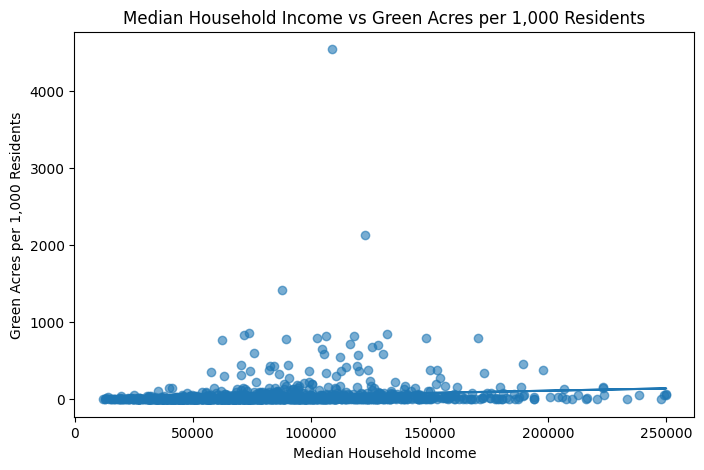

In [27]:
# scatter plot: income vs green acres per 1,000 residents
plot_df = tracts_final[["med_hh_income", "green_acres_per_1000"]].dropna()

x = plot_df["med_hh_income"]
y = plot_df["green_acres_per_1000"]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x))

plt.title("Median Household Income vs Green Acres per 1,000 Residents")
plt.xlabel("Median Household Income")
plt.ylabel("Green Acres per 1,000 Residents")
plt.show()

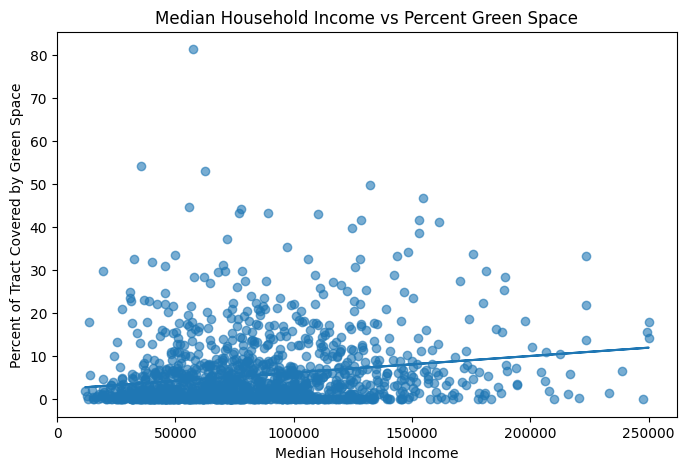

In [28]:
# scatter plot: income vs percent tract green space
plot_df = tracts_final[["med_hh_income", "green_pct_tract"]].dropna()

x = plot_df["med_hh_income"]
y = plot_df["green_pct_tract"]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x))

plt.title("Median Household Income vs Percent Green Space")
plt.xlabel("Median Household Income")
plt.ylabel("Percent of Tract Covered by Green Space")
plt.show()

<Figure size 800x500 with 0 Axes>

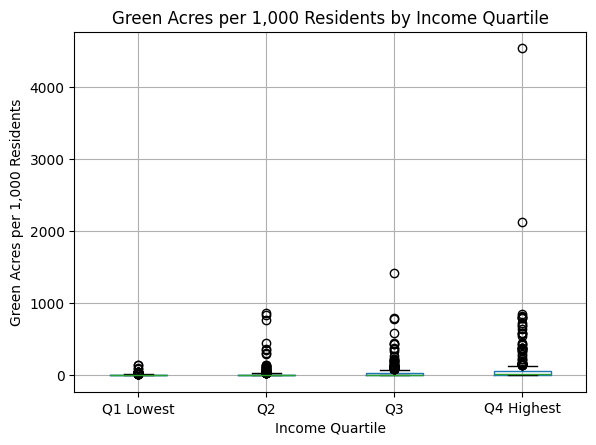

In [29]:
# boxplot by income quartile
tracts_final["income_quartile"] = pd.qcut(
    tracts_final["med_hh_income"],
    4,
    labels=["Q1 Lowest", "Q2", "Q3", "Q4 Highest"]
)

plt.figure(figsize=(8, 5))
tracts_final.boxplot(column="green_acres_per_1000", by="income_quartile")
plt.title("Green Acres per 1,000 Residents by Income Quartile")
plt.suptitle("")
plt.xlabel("Income Quartile")
plt.ylabel("Green Acres per 1,000 Residents")
plt.show()

Maps

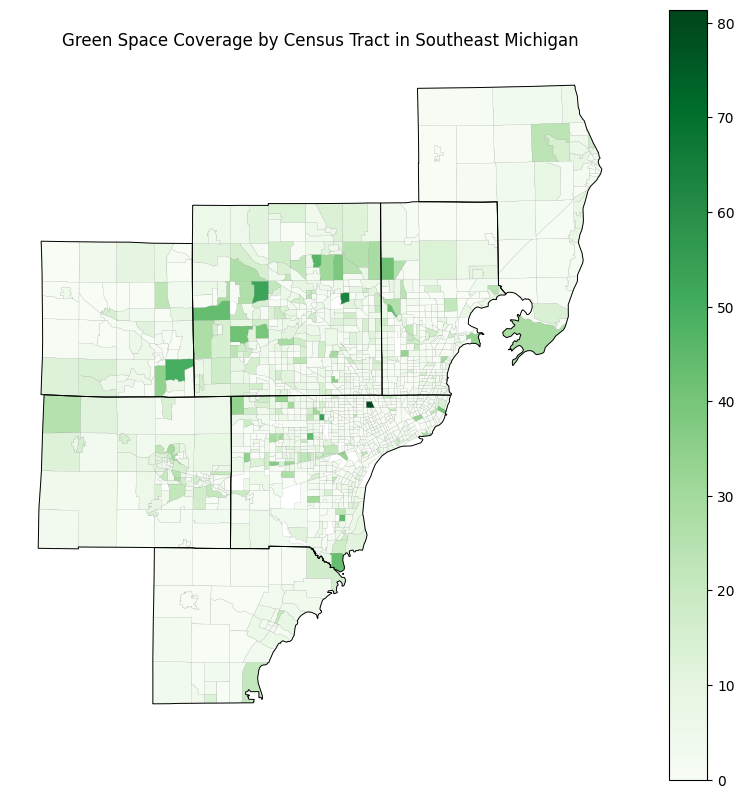

In [30]:
# Green space coverage choropleth
fig, ax = plt.subplots(figsize=(10, 10))

tracts_final.plot(
    column="green_pct_tract",
    cmap="Greens",
    legend=True,
    linewidth=0.1,
    edgecolor="gray",
    ax=ax
)

counties.boundary.plot(ax=ax, color="black", linewidth=0.7)

ax.set_title("Green Space Coverage by Census Tract in Southeast Michigan")
ax.axis("off")
plt.show()

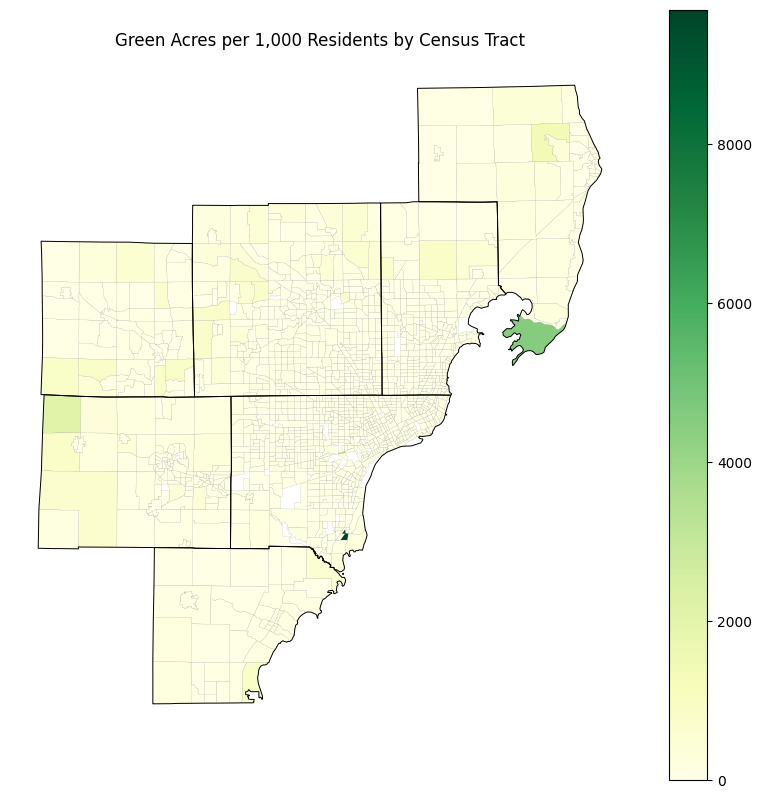

In [31]:
#Green acres per 1,000 choropleth
fig, ax = plt.subplots(figsize=(10, 10))

tracts_final.plot(
    column="green_acres_per_1000",
    cmap="YlGn",
    legend=True,
    linewidth=0.1,
    edgecolor="gray",
    ax=ax
)

counties.boundary.plot(ax=ax, color="black", linewidth=0.7)

ax.set_title("Green Acres per 1,000 Residents by Census Tract")
ax.axis("off")
plt.show()

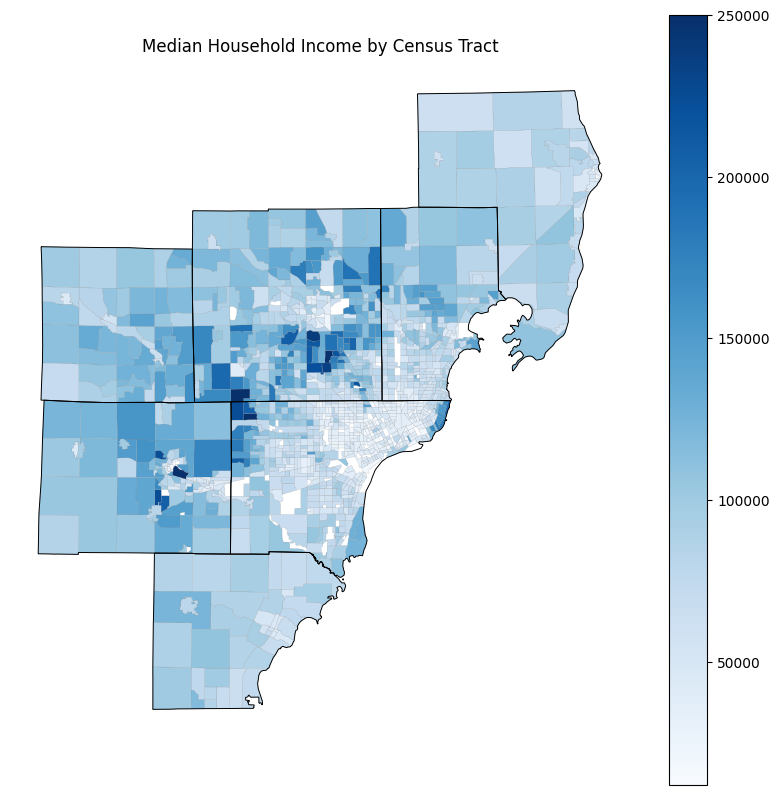

In [32]:
# Income choropleth
fig, ax = plt.subplots(figsize=(10, 10))

tracts_final.plot(
    column="med_hh_income",
    cmap="Blues",
    legend=True,
    linewidth=0.1,
    edgecolor="gray",
    ax=ax
)

counties.boundary.plot(ax=ax, color="black", linewidth=0.7)

ax.set_title("Median Household Income by Census Tract")
ax.axis("off")
plt.show()

# Findings
This map shows the distribution of median household income across census tracts in the study area. Darker shades represent higher income levels, while lighter shades indicate lower income areas. The pattern reveals that higher-income tracts are generally concentrated in suburban and peripheral areas, whereas lower-income tracts are more common in the urban core

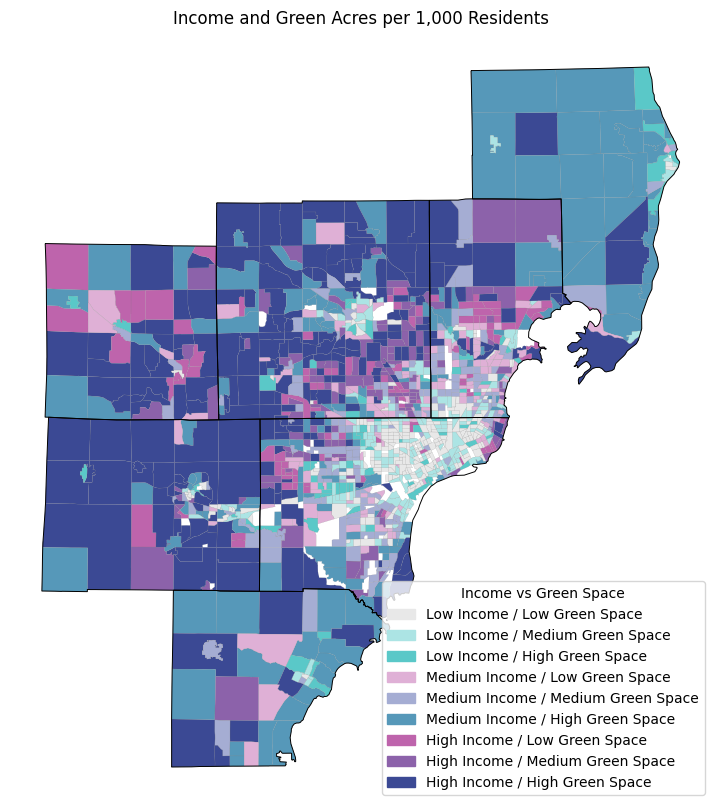

In [37]:
import matplotlib.patches as mpatches


tracts_final = tracts_final.dropna(subset=["med_hh_income", "green_acres_per_1000"]).copy()

tracts_final["income_q"] = pd.qcut(
    tracts_final["med_hh_income"], 3, labels=[1, 2, 3], duplicates="drop"
)
tracts_final["green_q"] = pd.qcut(
    tracts_final["green_acres_per_1000"], 3, labels=[1, 2, 3], duplicates="drop"
)


tracts_final["bivar"] = (
    tracts_final["income_q"].astype(str) + "-" +
    tracts_final["green_q"].astype(str)
)

bivar_colors = {
    "1-1": "#e8e8e8",
    "1-2": "#ace4e4",
    "1-3": "#5ac8c8",
    "2-1": "#dfb0d6",
    "2-2": "#a5add3",
    "2-3": "#5698b9",
    "3-1": "#be64ac",
    "3-2": "#8c62aa",
    "3-3": "#3b4994"
}


tracts_final["bivar_color"] = tracts_final["bivar"].map(bivar_colors)


tracts_plot = tracts_final.dropna(subset=["bivar_color"]).copy()

legend_labels = [
    ("1-1", "Low Income / Low Green Space"),
    ("1-2", "Low Income / Medium Green Space"),
    ("1-3", "Low Income / High Green Space"),
    ("2-1", "Medium Income / Low Green Space"),
    ("2-2", "Medium Income / Medium Green Space"),
    ("2-3", "Medium Income / High Green Space"),
    ("3-1", "High Income / Low Green Space"),
    ("3-2", "High Income / Medium Green Space"),
    ("3-3", "High Income / High Green Space"),
]

patches = [mpatches.Patch(color=bivar_colors[k], label=v) for k, v in legend_labels]


fig, ax = plt.subplots(figsize=(10, 10))

tracts_plot.plot(
    color=tracts_plot["bivar_color"],
    linewidth=0.1,
    edgecolor="gray",
    ax=ax
)

counties.boundary.plot(ax=ax, color="black", linewidth=0.7)

ax.legend(handles=patches, title="Income vs Green Space", loc="lower right")
ax.set_title("Income and Green Acres per 1,000 Residents")
ax.axis("off")

plt.show()

Findings
This bivariate map illustrates the spatial relationship between median household income and green space availability across the study area. By combining both variables into a single color scheme, the map reveals patterns of inequality in access to green space. Many urban or central areas are characterized by low to medium income and low green space, indicating limited access to environmental amenities. In contrast, suburban or less densely populated areas tend to exhibit higher levels of green space, regardless of income. Interestingly, some high-income areas still experience low green space availability, suggesting that access is not determined solely by income but also by factors such as land use and urban form.

In [1]:
# Connecting to ArcGIS Online
from arcgis.gis import GIS
def agol_login():
    import getpass
    print("Portal for ArcGIS as a built in user")
    pwd = getpass.getpass('PASSWORD: ')
    username = getpass.getpass('USERNAME: ')
    gis = GIS("https://wmugeography.maps.arcgis.com",username, pwd)
    print("Logged in as: " + gis.properties.user.username)
    return gis

In [39]:
gis = agol_login()

Portal for ArcGIS as a built in user
Logged in as: C_OwusuWMU


In [40]:
gdf= tracts_final
gdf.head()

,GEOID,NAME_x,COUNTYFP,TRACTCE,geometry,NAME_y,total_pop,med_hh_income,tract_sq_m,tract_acres,green_sq_m,green_acres,green_pct_tract,green_acres_per_1000,income_quartile,income_q,green_q,bivar,bivar_color
0,26093721100,7211,093,721100,"POLYGON ((251356.709 4740699.516, 252865.449 4...",Census Tract 7211; Livingston County; Michigan,3230,86250.0,9.940013e+07,24562.308161,4.327878e+06,1069.442039,4.353997,331.096606,Q3,2,3,2-3,#5698b9
1,26093713100,7131,093,713100,"POLYGON ((273818.939 4730429.732, 276441.511 4...",Census Tract 7131; Livingston County; Michigan,4949,117500.0,4.164815e+07,10291.483198,1.450924e+06,358.531221,3.483766,72.445185,Q4 Highest,3,3,3-3,#3b4994
2,26093741602,7416.02,093,741602,"POLYGON ((270642.225 4710835.013, 270762.284 4...",Census Tract 7416.02; Livingston County; Michigan,4086,110385.0,2.505669e+06,619.164274,0.000000e+00,0.000000,0.000000,0.000000,Q4 Highest,3,1,3-1,#be64ac
3,26093712101,7121.01,093,712101,"POLYGON ((261001.604 4730280.392, 264238.283 4...",Census Tract 7121.01; Livingston County; Michigan,3193,100740.0,2.310043e+07,5708.239352,0.000000e+00,0.000000,0.000000,0.000000,Q3,3,1,3-1,#be64ac
4,26093743500,7435,093,743500,"POLYGON ((260877.498 4706643.697, 261137.164 4...",Census Tract 7435; Livingston County; Michigan,1959,120341.0,4.374490e+06,1080.960090,1.250456e+05,30.899450,2.858519,15.773073,Q4 Highest,3,3,3-3,#3b4994


In [41]:
gdf.columns

Index(['GEOID', 'NAME_x', 'COUNTYFP', 'TRACTCE', 'geometry', 'NAME_y',
       'total_pop', 'med_hh_income', 'tract_sq_m', 'tract_acres', 'green_sq_m',
       'green_acres', 'green_pct_tract', 'green_acres_per_1000',
       'income_quartile', 'income_q', 'green_q', 'bivar', 'bivar_color'],
      dtype='object')

In [42]:
gdf.crs

<Projected CRS: EPSG:32617>
Name: WGS 84 / UTM zone 17N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 84°W and 78°W, northern hemisphere between equator and 84°N, onshore and offshore. Bahamas. Ecuador - north of equator. Canada - Nunavut; Ontario; Quebec. Cayman Islands. Colombia. Costa Rica. Cuba. Jamaica. Nicaragua. Panama. United States (USA).
- bounds: (-84.0, 0.0, -78.0, 84.0)
Coordinate Operation:
- name: UTM zone 17N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [43]:
gdf= gdf.to_crs(epsg=4326)

In [44]:
print(gdf.geometry.head())

0    POLYGON ((-84.03952 42.7785, -84.02109 42.7788...
1    POLYGON ((-83.76115 42.69308, -83.72918 42.694...
2    POLYGON ((-83.792 42.51588, -83.79058 42.51693...
3    POLYGON ((-83.91737 42.68786, -83.87793 42.689...
4    POLYGON ((-83.90897 42.47523, -83.90579 42.474...
Name: geometry, dtype: geometry


In [45]:
gdf.to_file("SEMCOG_Greenspace.geojson", driver = "GeoJSON")

<Axes: >

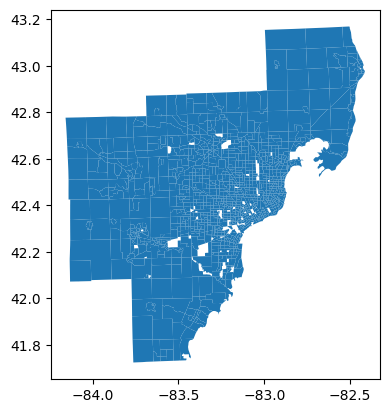

In [46]:
gdf.plot()

In [47]:
# create an item_properties dict
from arcgis.gis import GIS
item_properties = {
    "title": "SEMCOG_GreenSpace",
    "description": "This layer contains census tracts within the SEMCOG region used to analyze the spatial relationship between median household income and access to green space (park acres per 1,000 residents",
    "tags": "GEOG6670-4670",
    "type": "GeoJson"
}


geojson_item = gis.content.add(
    item_properties = item_properties,
    data = "SEMCOG_Greenspace.geojson" 
    )

    

new_service = geojson_item.publish()
new_service

c:\Users\oj640\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\interactiveshell.py:3747: DeprecatedWarning: add is deprecated as of 2.3.0 and has been removed in 3.0.0. Use `Folder.add()` instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
c:\Users\oj640\AppData\Local\Programs\Python\Python313\Lib\site-packages\arcgis\graph\data_model_types.py:68: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class GraphProperty(BaseModel):
c:\Users\oj640\AppData\Local\Programs\Python\Python313\Lib\site-packages\arcgis\graph\data_model_types.py:271: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class FieldIn

<Item title:"SEMCOG_GreenSpace" type:Feature Layer Collection owner:C_OwusuWMU>